読み込み完了
データ件数: 289
列名: ['日付', '球場', '球団', '対戦相手', 'ホーム/ビジター', '打者名', '打順', '守備位置', '投手名', '投手利き腕', 'イニング', '表裏', 'イニング内打席番号', '打席内球数', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', '最終投球結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打者走者アウト', '一塁走者進塁先', '一塁走者アウト', '二塁走者進塁先', '二塁走者アウト', '三塁走者進塁先', '三塁走者アウト', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WE推定方法_前', 'WE推定方法_後', 'WEサンプル数_前', 'WEサンプル数_後']
保存完了: output/4番打者_選手別集計.csv


,球団,打者名,打席数,RE24合計,WPA合計,打点合計,本塁打合計,1打席あたりRE24,1打席あたりWPA
16,日本ハム,野村 佑希,20,6.100,0.914363,7,0,0.305000,0.045718
6,ヤクルト,オスナ,13,3.578,0.617753,2,0,0.275231,0.047519
9,ロッテ,ソト,17,3.355,-0.314895,5,0,0.197353,-0.018523
13,巨人,岡本 和真,31,1.916,0.278473,4,0,0.061806,0.008983
19,西武,中村 剛也,4,1.261,0.434562,0,0,0.315250,0.108641
20,阪神,森下 翔太,31,1.240,0.356859,4,0,0.040000,0.011512
4,オリックス,西野 真弘,1,1.012,-0.108702,1,0,1.012000,-0.108702
10,ロッテ,ポランコ,5,0.681,-0.041264,1,0,0.136200,-0.008253
7,ヤクルト,サンタナ,11,0.661,0.091890,1,0,0.060091,0.008354
11,中日,山本 泰寛,1,0.106,0.000000,0,0,0.106000,0.000000


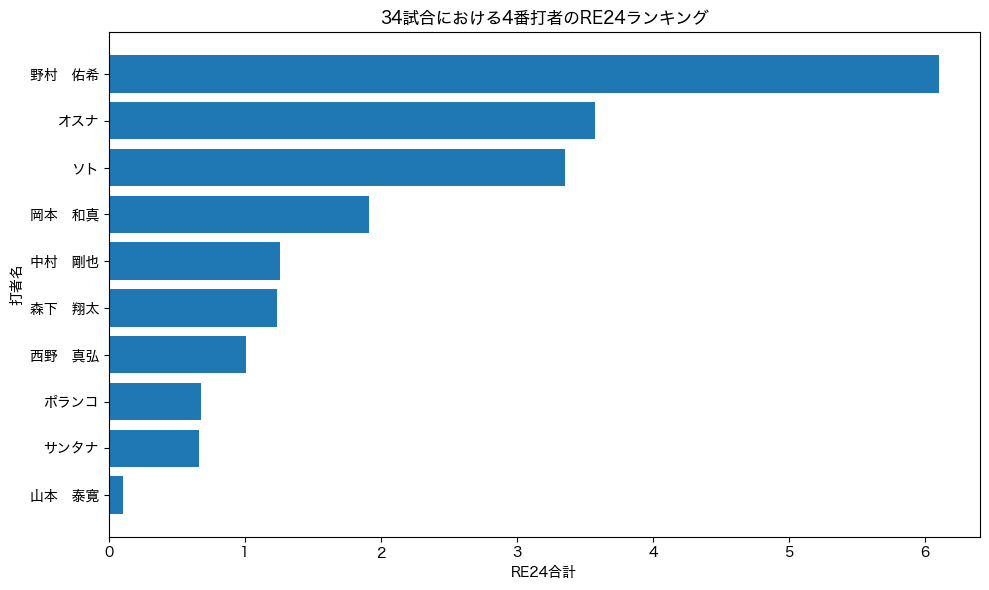

保存完了: output/RE24ランキング.png


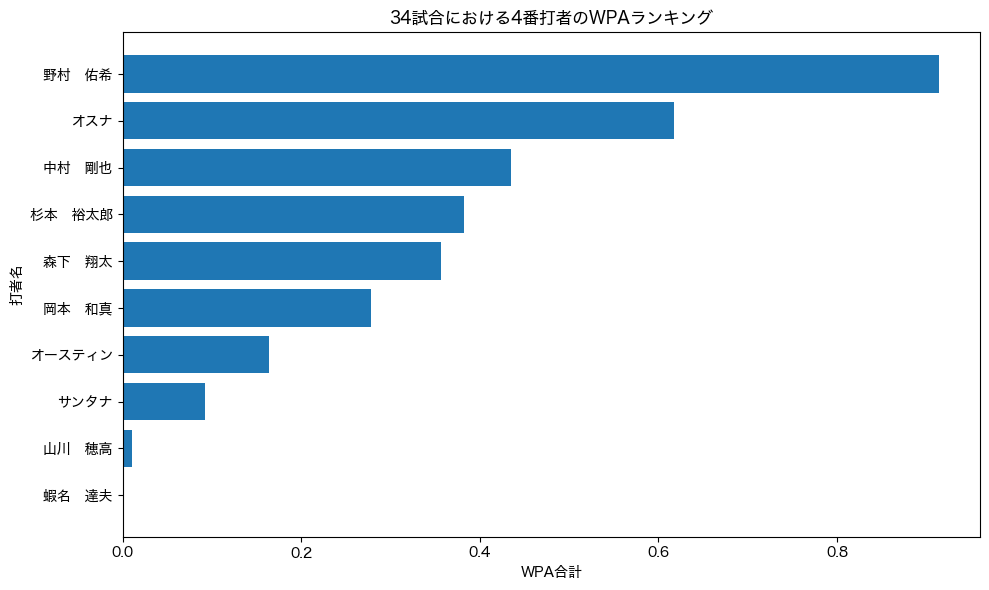

保存完了: output/WPAランキング.png


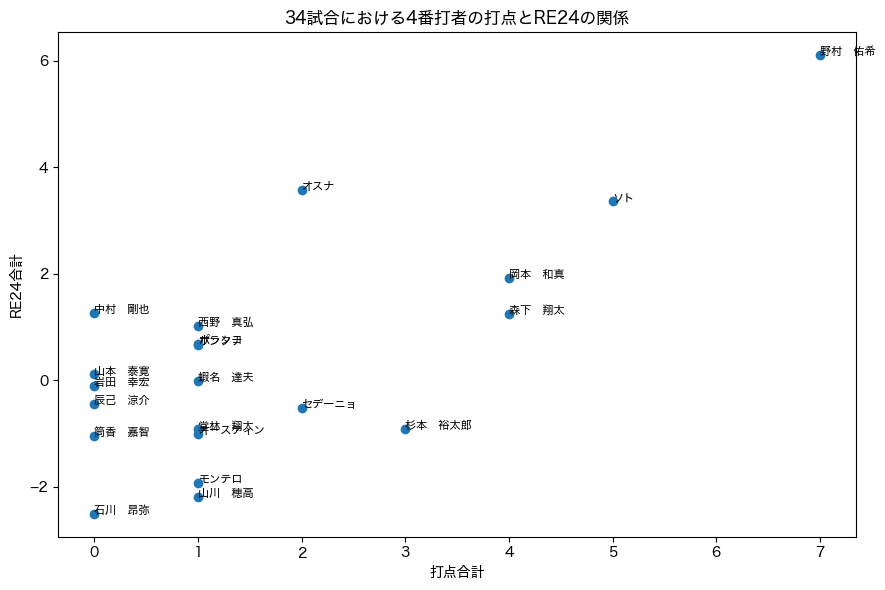

保存完了: output/打点とRE24の関係.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

# =========================
# 0. 日本語フォント設定（Mac用）
# =========================
matplotlib.rcParams["font.family"] = "Hiragino Sans"

# =========================
# 1. CSV読み込み
# =========================
DATA_PATH = Path("中間発表.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("読み込み完了")
print("データ件数:", len(df))
print("列名:", df.columns.tolist())

# =========================
# 2. 数値列を整える
# =========================
numeric_cols = ["RE24", "WPA", "打点"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# =========================
# 3. 本塁打列を作る
# =========================
if "打席結果" in df.columns:
    df["本塁打"] = df["打席結果"].astype(str).str.contains("本塁打|ホームラン|HR").astype(int)
else:
    df["本塁打"] = 0

# =========================
# 4. 選手別集計表を作る
# =========================
summary = (
    df.groupby(["球団", "打者名"], as_index=False)
    .agg(
        打席数=("打者名", "count"),
        RE24合計=("RE24", "sum"),
        WPA合計=("WPA", "sum"),
        打点合計=("打点", "sum"),
        本塁打合計=("本塁打", "sum"),
    )
)

summary["1打席あたりRE24"] = summary["RE24合計"] / summary["打席数"]
summary["1打席あたりWPA"] = summary["WPA合計"] / summary["打席数"]

summary = summary.sort_values("RE24合計", ascending=False)

# =========================
# 5. 集計表を保存
# =========================
summary.to_csv(
    OUTPUT_DIR / "4番打者_選手別集計.csv",
    index=False,
    encoding="utf-8-sig"
)

print("保存完了: output/4番打者_選手別集計.csv")

# 表を表示
display(summary)

# =========================
# 6. RE24ランキングのグラフ
# =========================
top_re24 = summary.sort_values("RE24合計", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_re24["打者名"], top_re24["RE24合計"])
plt.gca().invert_yaxis()
plt.xlabel("RE24合計")
plt.ylabel("打者名")
plt.title("34試合における4番打者のRE24ランキング")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RE24ランキング.png", dpi=300)
plt.show()

print("保存完了: output/RE24ランキング.png")

# =========================
# 7. WPAランキングのグラフ
# =========================
top_wpa = summary.sort_values("WPA合計", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_wpa["打者名"], top_wpa["WPA合計"])
plt.gca().invert_yaxis()
plt.xlabel("WPA合計")
plt.ylabel("打者名")
plt.title("34試合における4番打者のWPAランキング")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "WPAランキング.png", dpi=300)
plt.show()

print("保存完了: output/WPAランキング.png")

# =========================
# 8. 打点とRE24の関係
# =========================
plt.figure(figsize=(9, 6))
plt.scatter(summary["打点合計"], summary["RE24合計"])

for i, row in summary.iterrows():
    plt.text(row["打点合計"], row["RE24合計"], row["打者名"], fontsize=8)

plt.xlabel("打点合計")
plt.ylabel("RE24合計")
plt.title("34試合における4番打者の打点とRE24の関係")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "打点とRE24の関係.png", dpi=300)
plt.show()

print("保存完了: output/打点とRE24の関係.png")

NameError: name 'df' is not defined